In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
from google.colab import files
import zipfile

warnings.filterwarnings("ignore")

In [3]:
uploaded = files.upload()

with zipfile.ZipFile("archive.zip", "r") as z:
    z.extractall("netflix_data")

netflix = pd.read_csv("netflix_data/netflix_titles.csv")
print("✅ Dataset Loaded:", netflix.shape)
netflix.head(3)

Saving archive.zip to archive (1).zip
✅ Dataset Loaded: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [4]:
netflix.info()
print(netflix.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0


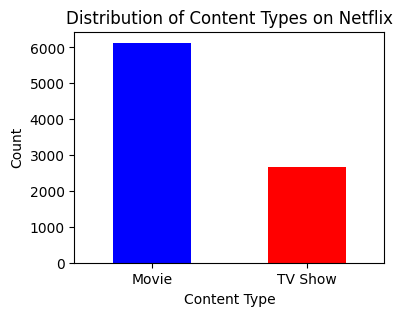

In [5]:
plt.figure(figsize=(4, 3))
netflix['type'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

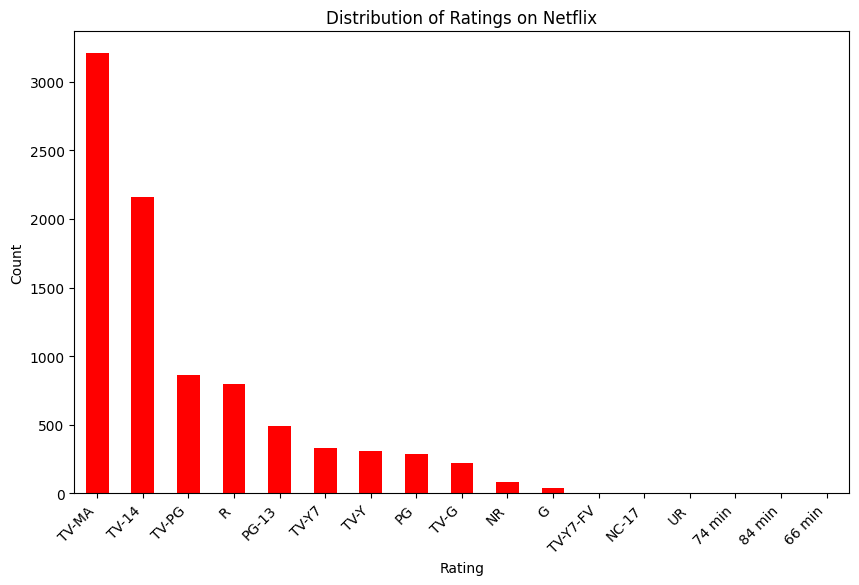

In [6]:
plt.figure(figsize=(10, 6))
netflix['rating'].value_counts().plot(kind='bar', color='red')
plt.title('Distribution of Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

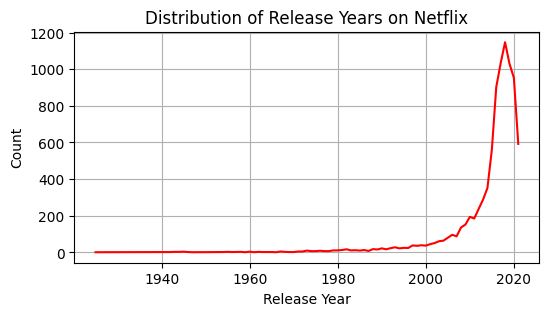

In [7]:
plt.figure(figsize=(6, 3))
netflix['release_year'].value_counts().sort_index().plot(kind='line', color='red')
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

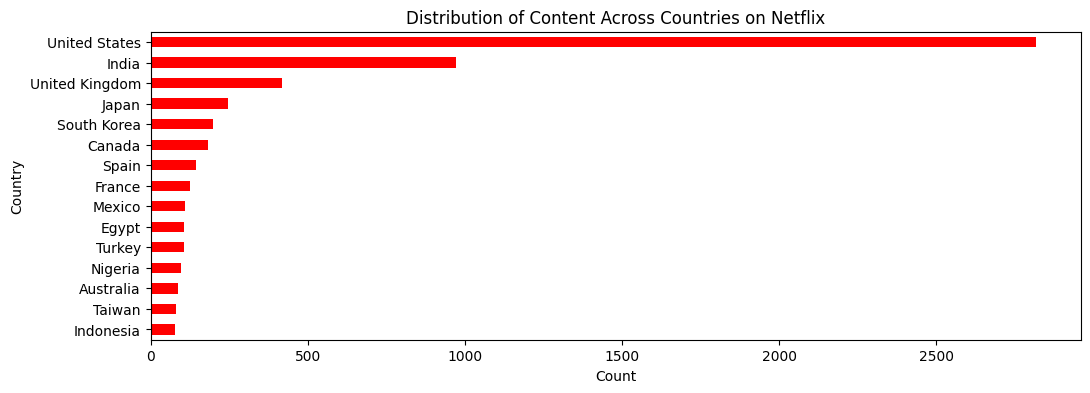

In [8]:
plt.figure(figsize=(12, 4))
netflix['country'].value_counts().head(15).plot(kind='barh', color='red')
plt.title('Distribution of Content Across Countries on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.show()

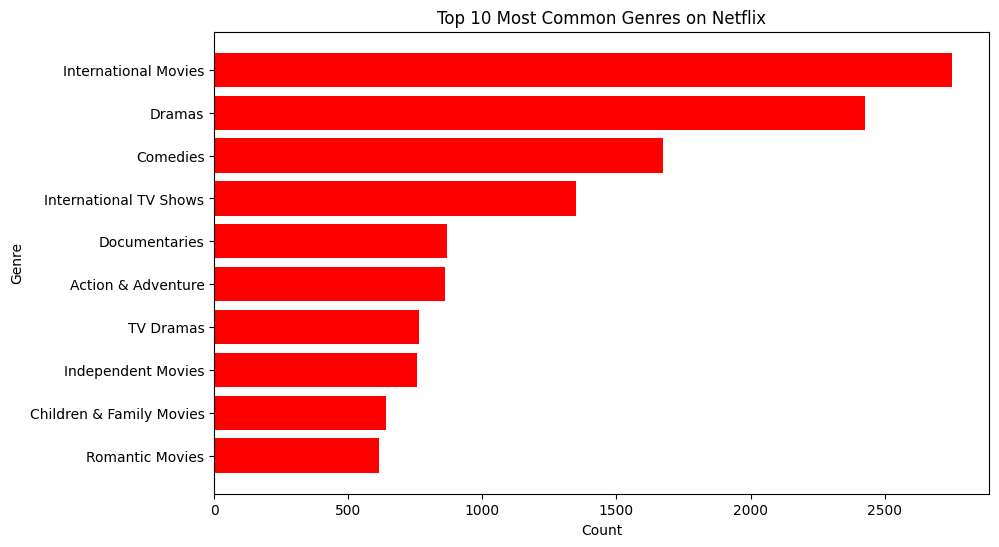

In [9]:
genres = netflix['listed_in'].apply(lambda x: x.split(', '))
genre_counts = Counter(genre for sublist in genres for genre in sublist)
top_genres = dict(genre_counts.most_common(10))

plt.figure(figsize=(10, 6))
plt.barh(list(top_genres.keys()), list(top_genres.values()), color='red')
plt.title('Top 10 Most Common Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()

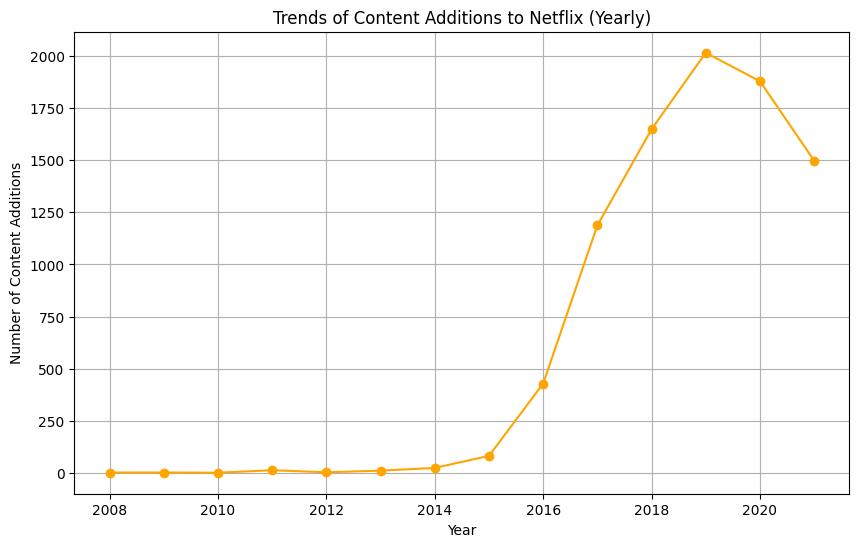

In [10]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'].str.strip(), format='%B %d, %Y')
netflix['year_added'] = netflix['date_added'].dt.year
content_by_year = netflix['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
content_by_year.plot(kind='line', marker='o', color='orange')
plt.title('Trends of Content Additions to Netflix (Yearly)')
plt.xlabel('Year')
plt.ylabel('Number of Content Additions')
plt.grid(True)
plt.show()